Found 2062 files belonging to 10 classes.
Using 1753 files for training.
Found 2062 files belonging to 10 classes.
Using 309 files for validation.
Epoch 1/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 215ms/step - accuracy: 0.0947 - loss: 2.3480 - val_accuracy: 0.0939 - val_loss: 2.3230 - learning_rate: 5.0000e-04
Epoch 2/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.1095 - loss: 2.3231 - val_accuracy: 0.1036 - val_loss: 2.3218 - learning_rate: 5.0000e-04
Epoch 3/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.1021 - loss: 2.3188 - val_accuracy: 0.1812 - val_loss: 2.3098 - learning_rate: 5.0000e-04
Epoch 4/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.1420 - loss: 2.3033 - val_accuracy: 0.3722 - val_loss: 2.2573 - learning_rate: 5.0000e-04
Epoch 5/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.2259 - loss: 2.2133 - val_accuracy: 0.3592 - val_loss: 2.0234 - learning_rate: 5.0000e-04
Epoch 6/45
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.292

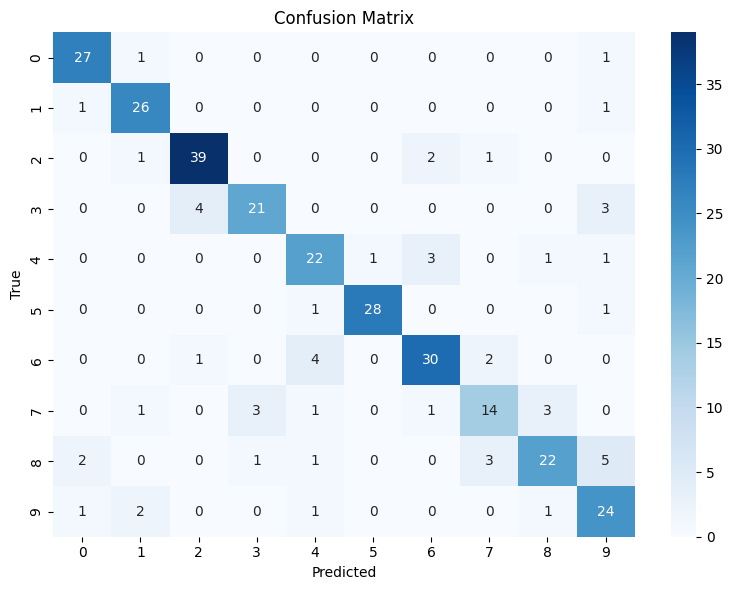

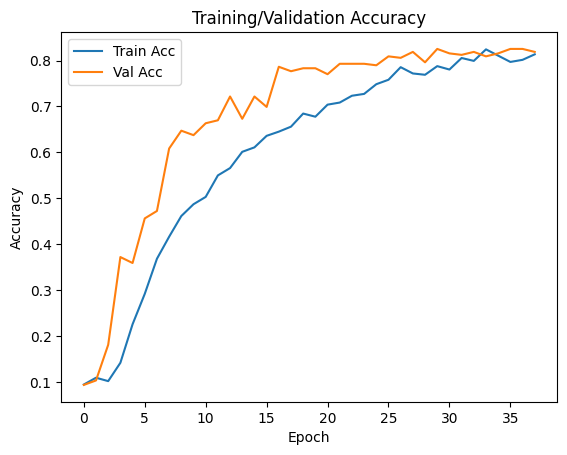

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

DATA_DIR = "C:/Users/wahee/Sign-Language-Digits-Dataset/Dataset"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
EPOCHS = 45
DROPOUT1 = 0.25
DROPOUT2 = 0.5
L2_LAMBDA = 0.0001
RESULTS_DIR = "experiment_results"
SEED = 123
# ----------------------------------------------

os.makedirs(RESULTS_DIR, exist_ok=True)

# Load dataset
train_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale',
    shuffle=True,
    validation_split=0.15,
    subset='training',
    seed=SEED
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale',
    shuffle=True,
    validation_split=0.15,
    subset='validation',
    seed=SEED
)

class_names = train_raw.class_names

# Preprocess
train_ds = train_raw.map(lambda x, y: (x/255.0, y))
val_ds   = val_raw.map(lambda x, y: (x/255.0, y))

# Augmentation
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.05),
])
train_ds = train_ds.map(lambda x, y: (data_aug(x, training=True), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# Build model
model = keras.Sequential([
    keras.Input(shape=(64,64,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(DROPOUT1),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(DROPOUT1),
    layers.Flatten(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(L2_LAMBDA)),
    layers.Dropout(DROPOUT2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
)

# Evaluate
test_loss, test_acc = model.evaluate(val_ds)

# Predictions for metrics
y_true = np.array([y.numpy() for _, y in val_ds.unbatch()])
y_probs = model.predict(val_ds)
y_pred = y_probs.argmax(axis=1)

# Save metrics
metrics = {
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "dropout1": DROPOUT1,
    "dropout2": DROPOUT2,
    "l2_lambda": L2_LAMBDA,
    "epochs_trained": len(history.history["loss"]),
    "validation_loss": float(test_loss),
    "validation_accuracy": float(test_acc)
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))

# Training curves
plt.figure()
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training/Validation Accuracy")
plt.savefig(os.path.join(RESULTS_DIR, "accuracy_curve.png"))

print("Experiment complete. Metrics and plots saved in", RESULTS_DIR)
